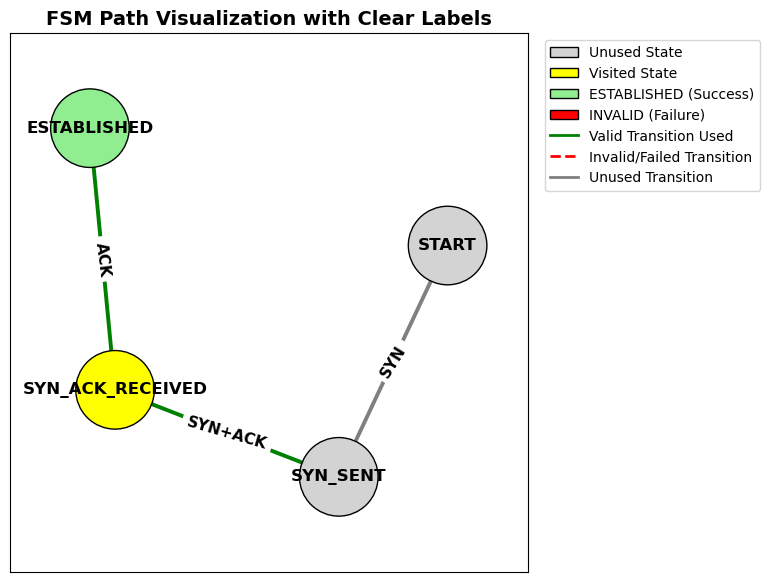

In [1]:
import tkinter as tk
from tkinter import ttk, messagebox
import networkx as nx
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List

# ---------------- FSM Definition ---------------- #
@dataclass
class FSMTraceItem:
    event: str
    state: str

class TCPFSM:
    def __init__(self, allow_retransmit=False, max_retries=2):
        self.allow_retransmit = allow_retransmit
        self.max_retries = max_retries
        self.reset()

    def reset(self):
        self.state = "START"
        self.retry_count = 0
        self.trace: List[FSMTraceItem] = []

    def transition(self, event: str):
        e = event.strip().upper()
        if self.state == "START":
            self.state = "SYN_SENT" if e == "SYN" else "INVALID"
        elif self.state == "SYN_SENT":
            if e == "SYN+ACK":
                self.state = "SYN_ACK_RECEIVED"
            elif e == "SYN" and self.allow_retransmit:
                self.retry_count += 1
                self.state = "SYN_SENT" if self.retry_count <= self.max_retries else "INVALID"
            else:
                self.state = "INVALID"
        elif self.state == "SYN_ACK_RECEIVED":
            self.state = "ESTABLISHED" if e == "ACK" else "INVALID"
        else:
            self.state = "INVALID"

        self.trace.append(FSMTraceItem(e, self.state))
        return self.state

    def run_sequence(self, seq: List[str]):
        self.reset()
        for ev in seq:
            s = self.transition(ev)
            if s == "INVALID":
                break
        return self.trace, self.state == "ESTABLISHED"


# ---------------- Temporal Logic Checks ---------------- #
def check_syn_eventually_ack(seq: List[str]) -> bool:
    """Every SYN is eventually followed by ACK"""
    for i, ev in enumerate(seq):
        if ev.upper() == "SYN" and not any(x.upper() == "ACK" for x in seq[i+1:]):
            return False
    return True

def check_no_ack_before_syn(seq: List[str]) -> bool:
    """No ACK before any SYN"""
    seen_syn = False
    for ev in seq:
        ev = ev.upper()
        if ev == "SYN":
            seen_syn = True
        elif ev == "ACK" and not seen_syn:
            return False
    return True

def check_established_is_terminal(trace: List[FSMTraceItem]) -> bool:
    """If ESTABLISHED occurs, no more valid transitions"""
    for i, t in enumerate(trace):
        if t.state == "ESTABLISHED":
            return all(x.state == "INVALID" for x in trace[i+1:])
    return True

def check_no_invalid_state(trace: List[FSMTraceItem]) -> bool:
    """No INVALID before the end"""
    if not trace:
        return True
    for t in trace[:-1]:
        if t.state == "INVALID":
            return False
    return True


# ---------------- FSM Drawing ---------------- #
def draw_fsm(trace=None):
    """
    FSM diagram with clear labels, spacing, and legend.
    Green edges → valid transitions used.
    Red dashed → invalid/failed transition.
    Gray → unused transitions.
    Node colors show visited/established/invalid states.
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    # Define FSM transitions
    edges = [
        ('START', 'SYN_SENT', 'SYN'),
        ('SYN_SENT', 'SYN_ACK_RECEIVED', 'SYN+ACK'),
        ('SYN_ACK_RECEIVED', 'ESTABLISHED', 'ACK'),
    ]

    G = nx.DiGraph()
    for u, v, lbl in edges:
        G.add_edge(u, v, label=lbl)

    # Use a more readable layout
    pos = nx.spring_layout(G, seed=42, k=1.5)  # k controls spacing

    # Track used edges/states
    used_edges = set()
    visited_states = set()
    invalid_edge = None

    if trace and len(trace) > 1:
        for i in range(1, len(trace)):
            prev_state = trace[i - 1].state if i > 0 else "START"
            curr_state = trace[i].state
            event = trace[i].event
            visited_states.add(curr_state)
            for (u, v, lbl) in edges:
                if lbl == event and u == prev_state and v == curr_state:
                    used_edges.add((u, v))
            if curr_state == "INVALID":
                invalid_edge = (prev_state, curr_state)

    # Edge colors and styles
    edge_colors, edge_styles = [], []
    for (u, v) in G.edges():
        if invalid_edge and (u, v) == invalid_edge:
            edge_colors.append("red")
            edge_styles.append("dashed")
        elif (u, v) in used_edges:
            edge_colors.append("green")
            edge_styles.append("solid")
        else:
            edge_colors.append("gray")
            edge_styles.append("solid")

    # Node colors
    node_colors = []
    for node in G.nodes():
        if node == "ESTABLISHED":
            node_colors.append("lightgreen")
        elif node == "INVALID":
            node_colors.append("red")
        elif node in visited_states:
            node_colors.append("yellow")
        else:
            node_colors.append("lightgray")

    # Plot setup
    fig, ax = plt.subplots(figsize=(9, 7))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3200, edgecolors='black', ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=12, font_weight='bold')

    # Draw edges (with dashed style for invalid)
    for (u, v), color, style in zip(G.edges(), edge_colors, edge_styles):
        nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=color, style=style, width=2.8, arrowsize=20, ax=ax)

    # Edge labels
    edge_labels = nx.get_edge_attributes(G, "label")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=11, font_weight='bold', ax=ax)

    # Add legend
    legend_elements = [
        Patch(facecolor='lightgray', edgecolor='black', label='Unused State'),
        Patch(facecolor='yellow', edgecolor='black', label='Visited State'),
        Patch(facecolor='lightgreen', edgecolor='black', label='ESTABLISHED (Success)'),
        Patch(facecolor='red', edgecolor='black', label='INVALID (Failure)'),
        Line2D([0], [0], color='green', lw=2, label='Valid Transition Used'),
        Line2D([0], [0], color='red', lw=2, linestyle='dashed', label='Invalid/Failed Transition'),
        Line2D([0], [0], color='gray', lw=2, label='Unused Transition')
    ]

    ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=10)
    ax.set_title("FSM Path Visualization with Clear Labels", fontsize=14, fontweight='bold')

    # Expand plot area so text doesn't get cut
    x_vals, y_vals = zip(*pos.values())
    ax.set_xlim(min(x_vals) - 0.4, max(x_vals) + 0.4)
    ax.set_ylim(min(y_vals) - 0.4, max(y_vals) + 0.4)
    plt.subplots_adjust(right=0.7)
    plt.show()


# ---------------- GUI ---------------- #
def launch_gui():
    last_trace = []

    def run_protocol_check():
        nonlocal last_trace
        seq_input = entry_seq.get().strip()
        if not seq_input:
            messagebox.showwarning("Input Error", "Enter a sequence like SYN,SYN+ACK,ACK")
            return
        seq = [x.strip() for x in seq_input.split(",") if x.strip()]
        fsm = TCPFSM(allow_retransmit=True)
        trace, accepted = fsm.run_sequence(seq)
        last_trace = fsm.trace

        ltl1 = check_syn_eventually_ack(seq)
        ltl2 = check_no_ack_before_syn(seq)
        ltl3 = check_established_is_terminal(fsm.trace)
        ltl4 = check_no_invalid_state(fsm.trace)

        result_text = (
            f"Result: {'ACCEPTED' if accepted else 'REJECTED'}\n"
            f"LTL1 (SYN→ACK): {ltl1}\n"
            f"LTL2 (No ACK before SYN): {ltl2}\n"
            f"LTL3 (Terminal ESTABLISHED): {ltl3}\n"
            f"LTL4 (No INVALID before end): {ltl4}\n"
        )
        text_output.delete("1.0", tk.END)
        text_output.insert(tk.END, result_text)

    def show_trace_diagram():
        if not last_trace:
            messagebox.showinfo("Info", "Run a sequence first to visualize its path.")
            return
        draw_fsm(last_trace)

    root = tk.Tk()
    root.title("Protocol Verification GUI")
    root.geometry("520x400")

    ttk.Label(root, text="Enter Protocol Sequence (comma-separated):").pack(pady=8)
    entry_seq = ttk.Entry(root, width=60)
    entry_seq.pack()

    ttk.Button(root, text="Run Verification", command=run_protocol_check).pack(pady=8)
    ttk.Button(root, text="Show FSM Diagram", command=show_trace_diagram).pack(pady=4)

    text_output = tk.Text(root, height=10, width=60)
    text_output.pack(pady=10)

    ttk.Button(root, text="Exit", command=root.destroy).pack(pady=5)
    root.mainloop()


if __name__ == "__main__":
    launch_gui()

